<a href="https://colab.research.google.com/github/ginasoft/vision-computacional/blob/main/Actividad_MaskRCNN_Cuellas_Natalia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Actividad Mask R-CNN - Vision Computacional UP
# Segmentacion de instancias con Mask R-CNN preentrenado (torchvision)

import torch
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Usando:", device)

# Carga del modelo preentrenado en COCO
# Incluye: backbone ResNet-50 + FPN, RPN, RoIAlign y las dos ramas (box/class y mask)
weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
model = maskrcnn_resnet50_fpn(weights=weights)
model.eval().to(device)

clases = weights.meta["categories"]  # nombres de las 80 clases de COCO
print("Modelo cargado. Cantidad de clases:", len(clases))

Usando: cuda
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 141MB/s]


Modelo cargado. Cantidad de clases: 91


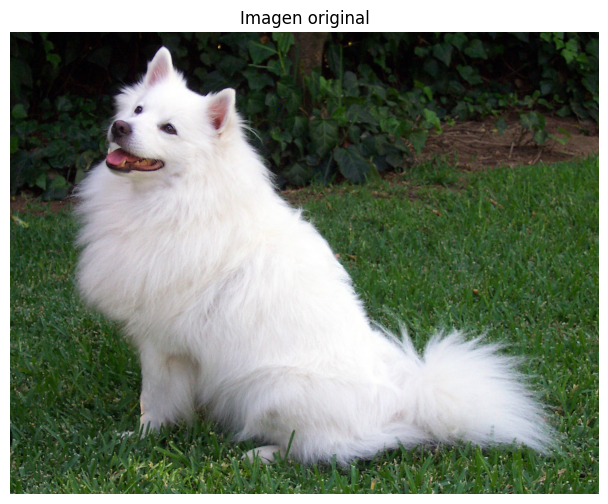

In [3]:
# Imagen de entrada (un gato, desde una URL de internet)
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"

# Algunos sitios bloquean descargas sin "navegador", por eso agregamos headers
headers = {"User-Agent": "Mozilla/5.0"}
respuesta = requests.get(url, headers=headers)
img_pil = Image.open(BytesIO(respuesta.content)).convert("RGB")

# Mostramos la imagen original antes de procesarla
plt.figure(figsize=(8, 6))
plt.imshow(img_pil)
plt.axis("off")
plt.title("Imagen original")
plt.show()

In [4]:
# Convertimos la imagen a tensor (formato que entiende el modelo)
img_tensor = torchvision.transforms.functional.to_tensor(img_pil).to(device)

# Inferencia: el modelo detecta y segmenta los objetos
# No ajusta pesos (no es entrenamiento), solo prediccion -> mas rapido
with torch.no_grad():
    pred = model([img_tensor])[0]

# Vemos cuantos objetos detecto en total
print("Objetos detectados:", len(pred["scores"]))
print("Primeras confianzas:", pred["scores"][:5])

Objetos detectados: 3
Primeras confianzas: tensor([0.8932, 0.6164, 0.0510], device='cuda:0')


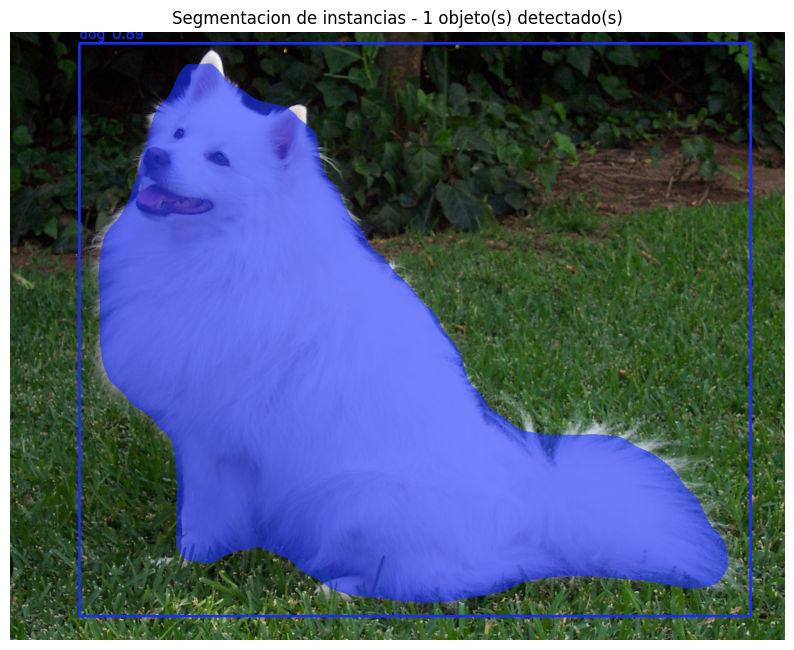

In [6]:
# Filtrado por confianza y dibujado de mascaras
umbral = 0.7
img_np = np.array(img_pil).copy()

detectados = 0
for i in range(len(pred["scores"])):
    score = pred["scores"][i].item()
    if score < umbral:
        continue  # descartamos las detecciones de baja confianza
    detectados += 1

    # Mascara binaria pixel a pixel (Rama B - FCN)
    # Cada pixel: 1 si pertenece al objeto, 0 si es fondo
    mask = pred["masks"][i, 0].cpu().numpy() > 0.5

    # Color aleatorio por instancia (segmentacion de instancias)
    color = np.random.randint(0, 255, 3)
    img_np[mask] = img_np[mask] * 0.4 + color * 0.6

    # Bounding box y etiqueta (Rama A - heredada de Faster R-CNN)
    x1, y1, x2, y2 = pred["boxes"][i].cpu().numpy().astype(int)
    etiqueta = clases[pred["labels"][i].item()]
    cv2.rectangle(img_np, (x1, y1), (x2, y2), color.tolist(), 3)
    cv2.putText(img_np, f"{etiqueta} {score:.2f}", (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, color.tolist(), 2)

# Mostramos el resultado final
plt.figure(figsize=(10, 8))
plt.imshow(img_np)
plt.axis("off")
plt.title(f"Segmentacion de instancias - {detectados} objeto(s) detectado(s)")
plt.show()